In [5]:
import json
import math
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def euclidean(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

def build_directional_nodes(swaths):
    """Creates two possible traversal directions for every single paint line."""
    nodes = []
    for i, s in enumerate(swaths):
        start, end = tuple(s["start"]), tuple(s["end"])
        nodes.append({"entry": start, "exit": end, "swath_idx": i, "direction": 0})
        nodes.append({"entry": end, "exit": start, "swath_idx": i, "direction": 1})
    return nodes

def build_distance_matrix(nodes, depot_point, scale=1000):
    """Builds the matrix of air-travel distances between the exit and entry of all lines."""
    size = len(nodes) + 1
    matrix = [[0] * size for _ in range(size)]

    for i in range(size):
        for j in range(size):
            if i == j:
                continue
            if i == 0:
                p_from, p_to = depot_point, nodes[j - 1]["entry"]
            elif j == 0:
                p_from, p_to = nodes[i - 1]["exit"], depot_point
            else:
                p_from, p_to = nodes[i - 1]["exit"], nodes[j - 1]["entry"]

            matrix[i][j] = int(round(euclidean(p_from, p_to) * scale))
    return matrix

def solve(swaths, depot_point, time_limit_seconds=10, verbose=True):
    """Configures Google OR-Tools and solves the TSP."""
    nodes = build_directional_nodes(swaths)
    n_swaths = len(swaths)
    distance_matrix = build_distance_matrix(nodes, depot_point)

    manager = pywrapcp.RoutingIndexManager(len(distance_matrix), 1, 0)
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        return distance_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    # Disjunction ensures the solver picks exactly ONE direction per swath
    penalty = 10 ** 9
    for i in range(n_swaths):
        index_a = manager.NodeToIndex(2 * i + 1)
        index_b = manager.NodeToIndex(2 * i + 2)
        routing.AddDisjunction([index_a, index_b], penalty, 1)

    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    search_parameters.time_limit.FromSeconds(time_limit_seconds)

    solution = routing.SolveWithParameters(search_parameters)

    if solution is None:
        raise RuntimeError("No solution found. Try increasing time_limit_seconds.")

    path_coords, visited_swaths = [], []
    total_air_distance = 0.0
    index = routing.Start(0)
    prev_exit_point = depot_point

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        if node != 0:
            n = nodes[node - 1]
            total_air_distance += euclidean(prev_exit_point, n["entry"])
            path_coords.extend([list(n["entry"]), list(n["exit"])])
            visited_swaths.append({"swath_idx": n["swath_idx"], "direction": n["direction"]})
            prev_exit_point = n["exit"]
        index = solution.Value(routing.NextVar(index))

    if verbose:
        print(f"Swaths in input:   {n_swaths}")
        print(f"Swaths routed:     {len(visited_swaths)}")
        print(f"Total in-air (travel) distance: {total_air_distance:.3f}")

    return path_coords, visited_swaths, total_air_distance

In [7]:
# 1. Load the JSON dictionary structure output by Person 1
data = load_json("generated_swaths.json")
swaths = data.get("swaths", [])
entry_dir = data.get("entry_direction", "south").lower()

# 2. Calculate the bounding box of all paint strokes
all_x = [pt[0] for s in swaths for pt in (s["start"], s["end"])]
all_y = [pt[1] for s in swaths for pt in (s["start"], s["end"])]

min_x, max_x = min(all_x), max(all_x)
min_y, max_y = min(all_y), max(all_y)
mid_x, mid_y = (min_x + max_x) / 2.0, (min_y + max_y) / 2.0

# 3. Place the Virtual Depot outside the bounding box based on direction
if entry_dir == "west": depot = (min_x - 5.0, mid_y)
elif entry_dir == "east": depot = (max_x + 5.0, mid_y)
elif entry_dir == "north": depot = (mid_x, max_y + 5.0)
elif entry_dir == "south": depot = (mid_x, min_y - 5.0)
else: depot = (mid_x, min_y - 5.0) # Default fallback

print(f"Entry Direction: {entry_dir.upper()}")
print(f"Virtual Depot created at: {depot}")

# 4. Solve the TSP
path, order, total_distance = solve(swaths, depot_point=depot)

# 5. Export for the visualizer or physical robot execution
with open("optimized_path.json", "w") as f:
    json.dump({
        "depot": list(depot),
        "path": path,
        "swath_order": order,
        "total_air_distance": total_distance,
    }, f, indent=2)
    
print("\nSaved result to optimized_path.json")

Entry Direction: WEST
Virtual Depot created at: (-4.4, 4.799999999999999)
Swaths in input:   12
Swaths routed:     12
Total in-air (travel) distance: 25.004

Saved result to optimized_path.json


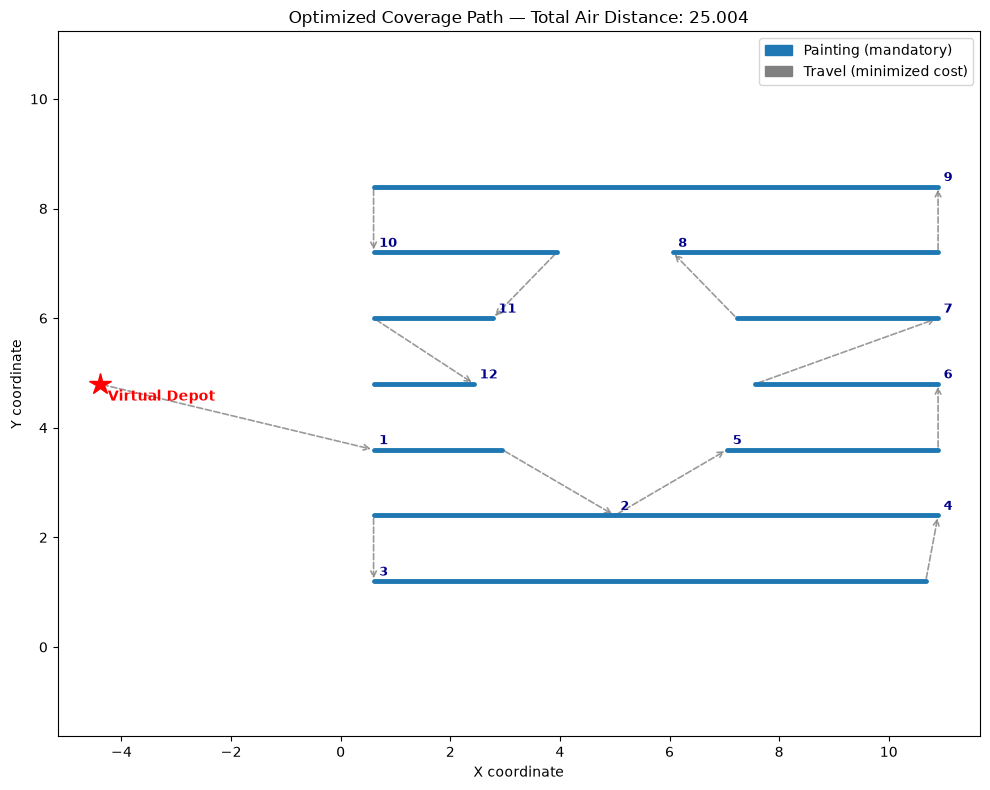

In [8]:
def plot_optimized_route():
    # Load geometries
    input_data = load_json("generated_swaths.json")
    swaths = input_data["swaths"]
    
    # Load solved route
    result = load_json("optimized_path.json")
    path = result["path"]
    depot = result["depot"]

    fig, ax = plt.subplots(figsize=(10, 8))

    # 1. Draw every swath faintly first as a reference
    for s in swaths:
        ax.plot([s["start"][0], s["end"][0]], [s["start"][1], s["end"][1]], 
                color="#cccccc", linewidth=2, zorder=1)

    # 2. Walk the solved route
    prev_exit = tuple(depot)
    for step, i in enumerate(range(0, len(path), 2)):
        entry = tuple(path[i])
        exit_ = tuple(path[i + 1])
        swath_number = step + 1

        # Travel segment (dashed arrow in the air)
        ax.annotate("", xy=entry, xytext=prev_exit,
                    arrowprops=dict(arrowstyle="->", color="gray", linestyle="dashed",
                                     linewidth=1.2, alpha=0.8), zorder=2)

        # Painting segment (solid color on the canvas)
        ax.plot([entry[0], exit_[0]], [entry[1], exit_[1]],
                 color="tab:blue", linewidth=3.5, solid_capstyle="round", zorder=3)

        # Label the order at the entry point
        ax.annotate(str(swath_number), xy=entry, xytext=(4, 4),
                    textcoords="offset points", fontsize=9, fontweight="bold",
                    color="darkblue", zorder=4)

        prev_exit = exit_

    # 3. Mark the Virtual Depot
    ax.plot(depot[0], depot[1], marker="*", color="red", markersize=16, zorder=5)
    ax.annotate("Virtual Depot", xy=depot, xytext=(6, -12), textcoords="offset points",
                color="red", fontsize=10, fontweight="bold")

    legend_handles = [
        mpatches.Patch(color="tab:blue", label="Painting (mandatory)"),
        mpatches.Patch(color="gray", label="Travel (minimized cost)"),
    ]
    ax.legend(handles=legend_handles, loc="upper right")

    ax.set_title(f"Optimized Coverage Path — Total Air Distance: {result['total_air_distance']:.3f}")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_optimized_route()